# Posterior entropy and memorization: verified DiT-L16 training sets

## Scope
Model-free Bayesian candidate-map identification, not a neural-model posterior or
a cosmological parameter posterior. No model inference, training, downloads, or
environment modifications. **Prepared, not yet scientifically executed.**

Rebuild each exact training set with its live `parse_config_data` loader. Reuse that
run's fitted log/center-max/tanh transformation for test and covariance-reference maps.
Do not apply PCA or pixel whitening. Training candidates have a uniform prior.

For each query, $\phi_t=\sqrt{\bar\alpha_t}\phi+\sqrt{1-\bar\alpha_t}\epsilon$,
$\log w_i=-\|\phi_t-\sqrt{\bar\alpha_t}\phi_i\|^2/[2(1-\bar\alpha_t)]$.
Report mean posterior entropy $S$ and $\ln N-S$ across 256 queries.
The entropy deficit is an empirical diagnostic, **not an exact estimate of the true
distribution's mutual information in all regimes** (Hunt et al., Eqs. 4–5, Fig. 3).

Fixed centered patches L=5,9,17,33,65,128 preserve candidate identity (one patch per map;
no translation pooling or D4 augmentation). A shared noise realization per query makes
noise-level comparisons reproducible; no Monte Carlo uncertainty band is claimed.

Gaussian comparison: mean ensemble-centered orthonormal-FFT power, then
$\frac12\sum_k\log(1+\mathrm{snr}\,P_k)$. No radial-bin weighting ambiguity.
For stationary fields it is the covariance Gaussian bound; for cropped/nonstationary
patches it is a looser Fourier-diagonal covariance bound (Hadamard inequality), not the
exact patch covariance log determinant. Finite-reference estimation can underestimate
population covariance, so the empirical curve is not a certified population bound.

This can be CPU-intensive at N=32768 and L=128. Run only in an allocated compute job;
the notebook never submits one. Outputs default off and use a unique subdirectory.

In [1]:
from pathlib import Path
import os, sys, json, hashlib, inspect, copy, datetime, uuid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_DIR = Path('/home/jiamingp/diffusion_models_repo')
RUNTIME_ROOT = Path('/home/jiamingp/Diffusion_model/cosmo_diffusion_main')
BASE = Path('/scratch/huterer_root/huterer0/jiamingp')
PLAN_PATHS = [BASE/'dit_l16_adalnzero_highn_screen_v1/plan.json',
              BASE/'dit_zero_remaining_300k_v1/plan.json']
SEED = 123
SAMPLE_LABEL = 'dpm50_n512'
N_TEST = 256
PATCH_SIZES = [5,9,17,33,65,128]
QUERY_BLOCK = 16
SAVE_OUTPUTS = False
OUTPUT_ROOT = PROJECT_DIR/'notebooks/executed/postior_entropy'
assert os.environ.get('SLURM_JOB_ID'), 'Run in an allocated compute shell, not a login node.'
sys.path.insert(0, str(PROJECT_DIR))
from simdiff_eval.torch_compat import install_torch_backend_compat
print(install_torch_backend_compat(entry_point='posterior_entropy_notebook'))
sys.path.insert(0, str(RUNTIME_ROOT))
import torch, yaml
from cosmodiff import utils
from diffusers import DDPMScheduler
from simdiff_eval.io import _streaming_source_specs, _selected_reference_slices
assert RUNTIME_ROOT.resolve() in Path(inspect.getsourcefile(utils)).resolve().parents
torch.set_num_threads(int(os.environ.get('SLURM_CPUS_PER_TASK', '2')))
def sha(path):
    h = hashlib.sha256()
    with open(path,'rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()

{'schema_version': 1, 'module_file': '/home/jiamingp/diffusion_models_repo/simdiff_eval/torch_compat.py', 'entry_points': ['posterior_entropy_notebook'], 'installed_attributes': ['compiler.is_compiling', 'compiler.is_exporting', 'distributed._functional_collectives', 'distributed.device_mesh', 'float4_e2m1fn_x2', 'float8_e4m3fnuz', 'float8_e5m2fnuz', 'float8_e8m0fnu', 'mps._is_compiled', 'mps.current_device', 'mps.current_stream', 'mps.device', 'mps.device_count', 'mps.get_device_name', 'mps.get_device_properties', 'mps.initial_seed', 'mps.is_available', 'mps.is_built', 'mps.manual_seed_all', 'mps.max_memory_allocated', 'mps.memory_allocated', 'mps.reset_peak_memory_stats', 'mps.set_device', 'mps.stream', 'npu', 'uint1', 'uint2', 'uint3', 'uint4', 'uint5', 'uint6', 'uint7', 'utils._pytree.register_pytree_node', 'xpu']}


## 1. Verify plans, receipts, sample hashes, and configs
Same admission rule as the PCA95 notebook; generated arrays are never used as queries.

In [2]:
runs, inventory = [], []
for plan_path in PLAN_PATHS:
    plan_hash = sha(plan_path)
    for row in json.loads(plan_path.read_text())['runs']:
        if int(row['num_layers']) != 16 or int(row['patch_size']) != 8: continue
        sample = Path(row['sample_path'].format(seed=SEED,sample_label=SAMPLE_LABEL))
        receipt = sample.with_suffix('.complete.json')
        item = dict(N=int(row['dataset_size']),run_name=row['run_name'],config=row['config'],
                    plan=str(plan_path),plan_sha256=plan_hash,sample=str(sample))
        if not sample.is_file() or not receipt.is_file():
            inventory.append(dict(item,status='missing sample or receipt')); continue
        saved = json.loads(receipt.read_text())
        assert saved['status']=='complete' and saved['plan_sha256']==plan_hash
        assert sha(sample)==saved['samples_sha256']
        config_hash=sha(row['config'])
        assert not row.get('config_sha256') or row['config_sha256']==config_hash
        item.update(config_sha256=config_hash,receipt_sha256=sha(receipt),samples_sha256=saved['samples_sha256'])
        runs.append(item); inventory.append(dict(item,status='verified'))
runs.sort(key=lambda r:r['N'])
assert runs and len({r['N'] for r in runs})==len(runs)
display(pd.DataFrame(inventory))
print('Missing sizes:', sorted({2**k for k in range(6,16)}-{r['N'] for r in runs}))
configs={r['N']:yaml.safe_load(Path(r['config']).read_text()) for r in runs}
for cfg in configs.values():
    assert cfg['data']['reshape']=='2d' and cfg['data']['keep_on_cpu']
    assert cfg['data']['transform']==['log'] and cfg['data']['normalization']=='tanh'
    assert cfg.get('augmentations') is None
    assert cfg['noise_scheduler']['class']=='DDPMScheduler'
    kw=cfg['noise_scheduler']['kwargs']
    assert kw['num_train_timesteps']==500 and kw['beta_schedule']=='squaredcos_cap_v2'
    assert kw['rescale_betas_zero_snr'] is True

,N,run_name,config,plan,plan_sha256,sample,config_sha256,receipt_sha256,samples_sha256,status
0,512,nf_fig2_dit_l16_d2p09_p8_adalnzero_fresh_30000...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,/scratch/huterer_root/huterer0/jiamingp/dit_l1...,339b119b6bb5d80bdfd5abac222d1d166c9198fb202bd5...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,71bc7cf127f0f3fc7f6894b25dd025b8fbfa4362c53364...,99bbdd1606637d22464c3f617be51303780183188e6544...,e59f82a194f4f5ba72fb84d3d007ae5b97a24acbbc8740...,verified
1,2048,nf_fig2_dit_l16_d2p11_p8_adalnzero_fresh_30000...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,/scratch/huterer_root/huterer0/jiamingp/dit_l1...,339b119b6bb5d80bdfd5abac222d1d166c9198fb202bd5...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,e379ca3bbf86a51cb5267f6dbc53fa5a50f07b9c144797...,93d87eb8b4015c76f600d6efc33e6642a55b170e49807f...,b4eff99d1bd7a82c1f060a2cd5908bf8247b8c6e16cdfa...,verified
2,8192,nf_fig2_dit_l16_d2p13_p8_adalnzero_fresh_30000...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,/scratch/huterer_root/huterer0/jiamingp/dit_l1...,339b119b6bb5d80bdfd5abac222d1d166c9198fb202bd5...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,3fcf18f0ae184a6f683fb8fabacb2f2260319765681eab...,c1bb1a9203e1d8ab070a3840a38127460fcbeb57cf410c...,ae25f082b83dfddc57da3e3c317fc1078f89d9d090574d...,verified
3,32768,nf_fig2_dit_l16_d2p15_p8_adalnzero_fresh_30000...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,/scratch/huterer_root/huterer0/jiamingp/dit_l1...,339b119b6bb5d80bdfd5abac222d1d166c9198fb202bd5...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,126265ca2487f537b93d5407d62b001e66952f6bd0993c...,da9a68fc9ed857dd9303fb961461af459186e3717af822...,1b5ebb77e9e8760bebde435fcdd52b6feade956cbe9257...,verified
4,64,nf_fig2_dit_l16_d2p06_p8_adalnzero_fresh_30000...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,/scratch/huterer_root/huterer0/jiamingp/dit_ze...,871732c704a32782f04cb5d827744c40b5435b49fde343...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,e0b70b14be94bd66d71415157fd33cb6440dcd23018e9b...,d0b3ba980618834dc32943d0e74a196c162f044523459a...,0e9b9452aba92b850e4c599d56cbb2c058de47b080c07c...,verified
5,128,nf_fig2_dit_l16_d2p07_p8_adalnzero_fresh_30000...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,/scratch/huterer_root/huterer0/jiamingp/dit_ze...,871732c704a32782f04cb5d827744c40b5435b49fde343...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,6b4ebe87f465e8802f7fe085b1550ae8a82c4989c97a44...,95f9a4a1afd96ab1a778006ac13f042d34419f5e6a403c...,d969892f2b454290318a752a915e02024f9349e2f719e1...,verified
6,1024,nf_fig2_dit_l16_d2p10_p8_adalnzero_fresh_30000...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,/scratch/huterer_root/huterer0/jiamingp/dit_ze...,871732c704a32782f04cb5d827744c40b5435b49fde343...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,7bda2d17fd54dccccf5b4f5af3a9fceefc33c12e4b3cbd...,db1d93750e6653d1fe8403510712e67fb4e3ddfdbb2ea4...,dbfff1426afa84d6d8a7fbd9e1b3711544a70076ed91ba...,verified
7,4096,nf_fig2_dit_l16_d2p12_p8_adalnzero_fresh_30000...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,/scratch/huterer_root/huterer0/jiamingp/dit_ze...,871732c704a32782f04cb5d827744c40b5435b49fde343...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,dead714617d2774414c9ebe3b3f03fdcac8c6466c66849...,68aa1a737a0fcfbdd4736ca3819e783c8078d634708d02...,af3e049e7f0334b840e2ce3727a20304ca77823d146742...,verified
8,16384,nf_fig2_dit_l16_d2p14_p8_adalnzero_fresh_30000...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,/scratch/huterer_root/huterer0/jiamingp/dit_ze...,871732c704a32782f04cb5d827744c40b5435b49fde343...,/gpfs/accounts/huterer_root/huterer0/jiamingp/...,563c86c29b5e69e2e4f689f75d080d0e70aa01e880901b...,61544d58529156cd7bfc128f6998d0d13e09568cca85b7...,41bbb0cfbe848b4d5f0ee05ee65b2f57e38d8d47684c0e...,verified


Missing sizes: [256]


## 2. Fixed held-out queries and real covariance reference
Choose unselected raw simulation volumes from the largest run's source grids, excluding
every selected volume across all admitted runs. Use z=0, at most one map per volume;
round-robin across source grids, with seeded random ordering within a grid. This is map/
source-volume exclusion, not guaranteed simulation-level exclusion across redshifts.
Stop if 256 candidates are unavailable. Save every query's source, volume and slice ID.
The covariance reference is all exact training slices of the largest admitted run,
renormalized using each evaluated run's fitted normalization.

In [3]:
specs_by_n={n:_streaming_source_specs(cfg['data']) for n,cfg in configs.items()}
excluded={}
for specs in specs_by_n.values():
    for s in specs:
        excluded.setdefault(str(Path(s['path']).resolve()),set()).update(map(int,s['selected']))
largest_n=max(configs)
largest_specs=specs_by_n[largest_n]
rng=np.random.default_rng(SEED)
pools=[]
for s in largest_specs:
    path=str(Path(s['path']).resolve()); a=s['array']
    assert a.ndim==4 and a.shape[-2:]==(128,128)
    free=np.array(sorted(set(range(len(a)))-excluded[path]),dtype=int)
    pools.append(list(rng.permutation(free)))
query_ids=[]; query_maps=[]
while len(query_maps)<N_TEST and any(pools):
    for s,pool in zip(largest_specs,pools):
        if not pool or len(query_maps)==N_TEST: continue
        index=int(pool.pop())
        query_ids.append(dict(path=str(Path(s['path']).resolve()),raw_index=index,z_index=0))
        query_maps.append(np.array(s['array'][index,0],dtype=np.float32,copy=True))
assert len(query_maps)==N_TEST, 'Not enough held-out source volumes; do not reuse training maps.'
heldout_raw=np.stack(query_maps)[:,None]
reference_raw=_selected_reference_slices(largest_specs,configs[largest_n]['data'],None)[:,None]
assert len(reference_raw)==largest_n
provenance=dict(runs=runs,inventory=inventory,query_ids=query_ids,seed=SEED,
    covariance_reference_N=largest_n,patch_policy='centered fixed patch; one candidate per map',
    runtime_source=str(inspect.getsourcefile(utils)),runtime_sha256=sha(inspect.getsourcefile(utils)),
    torch_version=torch.__version__,normalizations={},schedules={},
    caveat='Current runtime reconstruction; historical runtime identity not independently established.')

## 3. Stable posterior calculation
Use float64 distances, subtract the maximum log weight, and compute entropy as
log(sum exp shifted logits) minus the weighted shifted logit. Pairwise dot products
are reused across 25 noise levels. No nearest-neighbor truncation: every one of N
training maps participates. Small unit checks run before the expensive calculation.

In [4]:
def entropy_logits(logits):
    shifted=logits-logits.max(axis=1,keepdims=True)
    weights=np.exp(shifted)
    total=weights.sum(axis=1)
    return np.log(total)-(weights*shifted).sum(axis=1)/total
assert np.allclose(entropy_logits(np.zeros((2,8))),np.log(8))
assert entropy_logits(np.array([[0.,-1000.]]))[0]<1e-10

def patch(a,L):
    start=(128-L)//2
    return a[:,0,start:start+L,start:start+L]

def schedule_grid(cfg):
    scheduler=DDPMScheduler(**cfg['noise_scheduler']['kwargs'])
    abar=scheduler.alphas_cumprod.cpu().numpy().astype(np.float64)
    ratio=np.divide(1-abar,abar,out=np.full_like(abar,np.inf),where=abar>0)
    valid=np.flatnonzero((ratio>=1e-3)&(ratio<=1e2))
    assert len(valid)>=25
    # Nearest log-spaced targets, constrained to strictly increasing distinct timesteps.
    targets=np.geomspace(1e-3,1e2,25); indices=[]; lower=0
    for j,target in enumerate(targets):
        upper=len(valid)-(25-j)+1
        choices=valid[lower:upper]
        chosen=int(choices[np.argmin(abs(np.log(ratio[choices])-np.log(target)))])
        indices.append(chosen); lower=int(np.where(valid==chosen)[0][0])+1
    return [(t,float(abar[t]),float(ratio[t])) for t in indices]

def calculate(train, query, reference, grid, N, L):
    t=patch(train,L).reshape(N,-1).astype(np.float64)
    q=patch(query,L).reshape(N_TEST,-1).astype(np.float64)
    noise=patch(np.random.default_rng(SEED+1).standard_normal(query.shape).astype(np.float32),L).reshape(N_TEST,-1).astype(np.float64)
    norms=(t*t).sum(axis=1)
    totals=np.zeros(len(grid))
    for start in range(0,N_TEST,QUERY_BLOCK):
        clean=q[start:start+QUERY_BLOCK]; eps=noise[start:start+QUERY_BLOCK]
        qt=clean@t.T; et=eps@t.T
        for j,(_,a,_) in enumerate(grid):
            noisy=np.sqrt(a)*clean+np.sqrt(1-a)*eps
            dist=(noisy*noisy).sum(axis=1)[:,None]+a*norms[None,:]-2*(a*qt+np.sqrt(a*(1-a))*et)
            assert dist.min()>-1e-5, 'Unexpected negative squared distances'
            h=entropy_logits(-np.maximum(dist,0)/(2*(1-a)))
            assert h.min()>-1e-8 and h.max()<=np.log(N)+1e-8
            totals[j]+=h.sum()
    # Diagonal covariance in an orthonormal Fourier basis, unbiased across maps.
    mean=np.zeros((L,L),dtype=np.complex128); second=np.zeros((L,L)); count=0
    for start in range(0,len(reference),128):
        f=np.fft.fft2(patch(reference[start:start+128],L),norm='ortho')
        mean+=f.sum(axis=0); second+=(abs(f)**2).sum(axis=0); count+=len(f)
    power=np.maximum((second-abs(mean)**2/count)/(count-1),0)
    rows=[]
    for j,(step,a,sigma2) in enumerate(grid):
        S=float(totals[j]/N_TEST)
        rows.append(dict(N=N,L=L,timestep=step,alpha_bar=a,sigma2=sigma2,S=S,
            entropy_deficit=float(np.log(N)-S),lnN=float(np.log(N)),n_queries=N_TEST,
            gaussian_fourier_bound=float(.5*np.log1p((a/(1-a))*power).sum())))
    return rows

## 4. Run the diagnostic
This cell loads real arrays and performs substantial CPU matrix products. No neural
checkpoint is loaded. Center/xmax are obtained from `parse_config_data`, not refitted
on test maps. Data identities are recorded; hashes of normalized training tensors are
also retained. Initial normalization reconstruction can require considerable RAM.

In [5]:
records=[]
for run in runs:
    N=run['N']; cfg=configs[N]
    built=utils.parse_config_data(copy.deepcopy(cfg))
    dataset=built['data']; norm=built['norm']; transform=built['tform']
    assert dataset.augmentations is None and len(dataset)==N
    assert norm.kwargs.get('center') is not None and norm.kwargs.get('xmax') is not None
    train=dataset.arrays.detach().cpu().numpy()
    assert train.shape==(N,1,128,128) and np.isfinite(train).all()
    def normalize(raw):
        parts=[]
        for start in range(0,len(raw),128):
            x=torch.from_numpy(np.array(raw[start:start+128],copy=True))
            with torch.no_grad(): y=norm(transform(x))
            parts.append(y.cpu().numpy())
        return np.concatenate(parts)
    # Validate raw-source selection order and fitted transform against actual loader.
    raw_train=_selected_reference_slices(specs_by_n[N],cfg['data'],None)[:,None]
    rebuilt=normalize(raw_train)
    assert np.allclose(train,rebuilt,atol=2e-6,rtol=2e-6), 'Training subset reconstruction mismatch'
    del rebuilt,raw_train
    query=normalize(heldout_raw); reference=normalize(reference_raw)
    assert np.isfinite(query).all() and np.isfinite(reference).all()
    provenance['normalizations'][str(N)]=dict(norm.kwargs)
    run['normalized_training_sha256']=hashlib.sha256(np.ascontiguousarray(train).tobytes()).hexdigest()
    grid=schedule_grid(cfg); provenance['schedules'][str(N)]=grid
    for L in PATCH_SIZES:
        print('Computing N=',N,'L=',L,flush=True)
        records.extend(calculate(train,query,reference,grid,N,L))
    del train,query,reference,built,dataset
summary=pd.DataFrame(records)
assert len(summary)==len(runs)*len(PATCH_SIZES)*25
display(summary.head())

/home/jiamingp/Diffusion_model/cosmo_diffusion_main/cosmodiff/utils.py:331: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  images = torch.as_tensor(images, device=device, dtype=dtype)


Computing N= 64 L= 5
Computing N= 64 L= 9
Computing N= 64 L= 17
Computing N= 64 L= 33
Computing N= 64 L= 65
Computing N= 64 L= 128
Computing N= 128 L= 5
Computing N= 128 L= 9
Computing N= 128 L= 17
Computing N= 128 L= 33
Computing N= 128 L= 65
Computing N= 128 L= 128
Computing N= 512 L= 5
Computing N= 512 L= 9
Computing N= 512 L= 17
Computing N= 512 L= 33
Computing N= 512 L= 65
Computing N= 512 L= 128
Computing N= 1024 L= 5
Computing N= 1024 L= 9
Computing N= 1024 L= 17
Computing N= 1024 L= 33
Computing N= 1024 L= 65
Computing N= 1024 L= 128
Computing N= 2048 L= 5
Computing N= 2048 L= 9
Computing N= 2048 L= 17
Computing N= 2048 L= 33
Computing N= 2048 L= 65
Computing N= 2048 L= 128
Computing N= 4096 L= 5
Computing N= 4096 L= 9
Computing N= 4096 L= 17
Computing N= 4096 L= 33
Computing N= 4096 L= 65
Computing N= 4096 L= 128
Computing N= 8192 L= 5
Computing N= 8192 L= 9
Computing N= 8192 L= 17
Computing N= 8192 L= 33
Computing N= 8192 L= 65
Computing N= 8192 L= 128
Computing N= 16384 L= 5

,N,L,timestep,alpha_bar,sigma2,S,entropy_deficit,lnN,n_queries,gaussian_fourier_bound
0,64,5,6,0.998980,0.001021,0.092471,4.066412,4.158883,256,24.213432
1,64,5,9,0.998252,0.001751,0.164144,3.994739,4.158883,256,19.294183
2,64,5,12,0.997350,0.002657,0.251090,3.907793,4.158883,256,15.910555
3,64,5,16,0.995877,0.004140,0.366385,3.792498,4.158883,256,12.745784
4,64,5,22,0.993089,0.006959,0.573910,3.584973,4.158883,256,9.621403


## 5. Crossings and figures
For each N and L, report the largest sampled noise-to-signal ratio with mean S<1 nat
and the next sampled ratio with S≥1, if present. These are grid brackets, not fitted
critical points. Nonmonotonic sample estimates are flagged, not forced monotonic.

,N,L,last_sigma2_S_below_1,next_sigma2_S_at_least_1,status,nonmonotonic
5,64,128,9.046970,14.655081,bracketed,True
11,128,128,9.046970,14.655081,bracketed,True
17,512,128,5.628746,9.046970,bracketed,True
23,1024,128,5.628746,9.046970,bracketed,True
29,2048,128,3.474324,5.628746,bracketed,True
35,4096,128,3.474324,5.628746,bracketed,True
41,8192,128,3.474324,5.628746,bracketed,True
47,16384,128,2.151292,3.474324,bracketed,False
53,32768,128,2.151292,3.474324,bracketed,False


,N,L,last_sigma2_S_below_1,next_sigma2_S_at_least_1,status,nonmonotonic
0,64,5,0.011157,0.018021,bracketed,False
1,64,9,0.046138,0.075269,bracketed,False
2,64,17,0.196738,0.314382,bracketed,False
3,64,33,0.829061,1.333265,bracketed,False
4,64,65,3.474324,5.628746,bracketed,True
5,64,128,9.046970,14.655081,bracketed,True
6,128,5,0.006959,0.011157,bracketed,False
7,128,9,0.028711,0.046138,bracketed,False
8,128,17,0.122279,0.196738,bracketed,True
9,128,33,0.509964,0.829061,bracketed,True


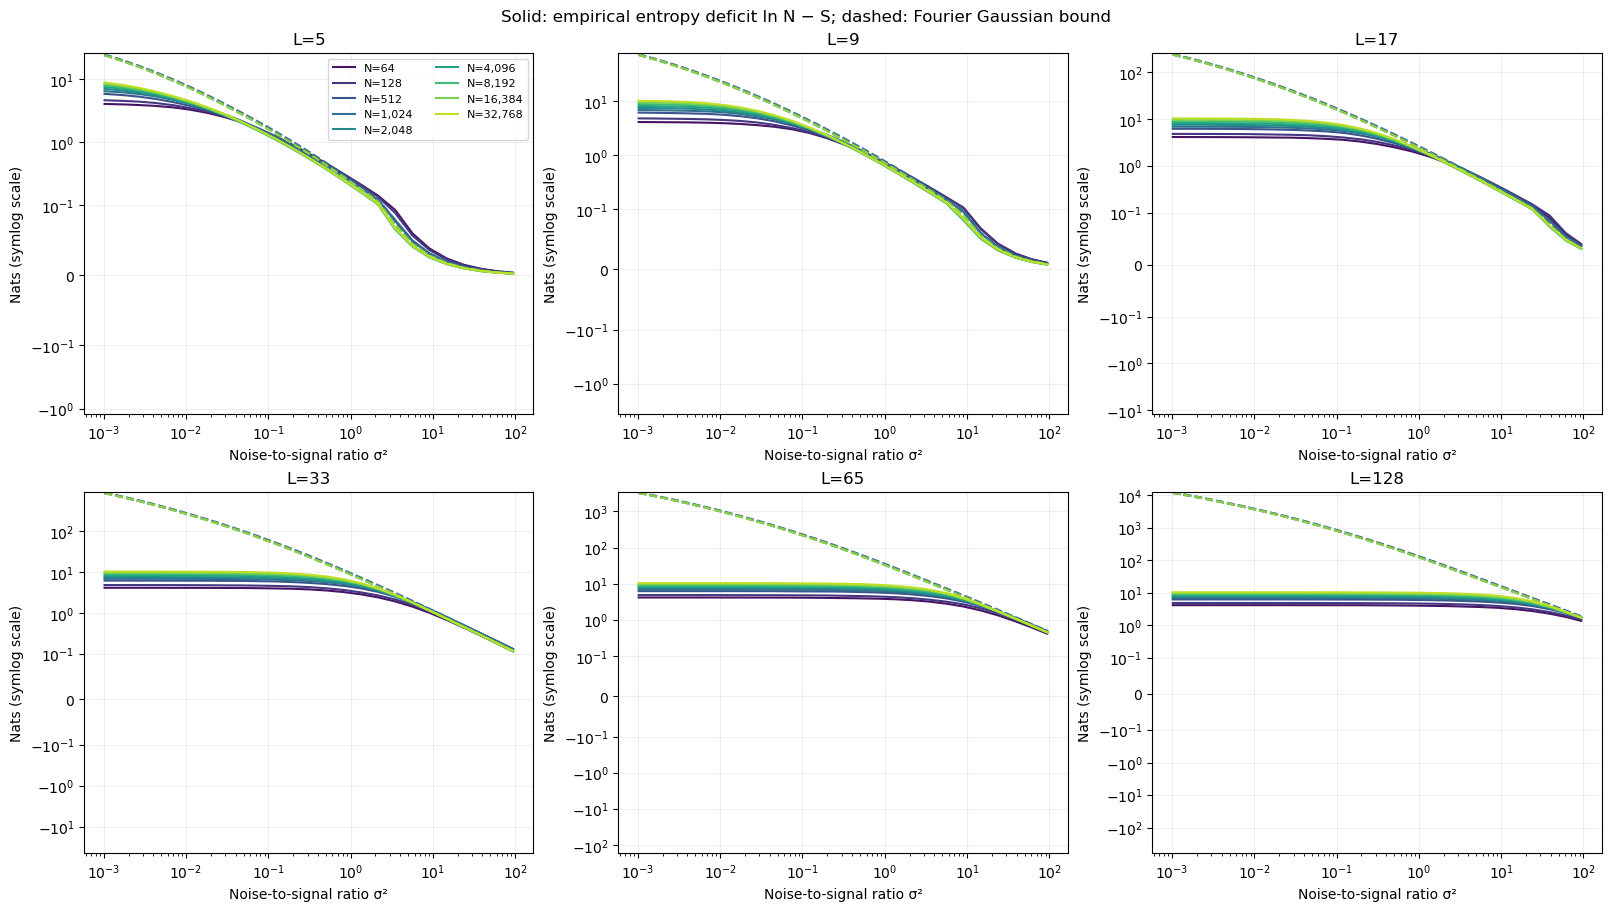

In [6]:
crossings=[]
for (N,L),frame in summary.groupby(['N','L']):
    frame=frame.sort_values('sigma2'); below=frame[frame.S<1]
    last=float(below.sigma2.max()) if len(below) else None
    above=frame[(frame.sigma2>last)&(frame.S>=1)] if last is not None else frame.iloc[:0]
    crossings.append(dict(N=N,L=L,last_sigma2_S_below_1=last,
        next_sigma2_S_at_least_1=float(above.sigma2.min()) if len(above) else None,
        status='never below 1' if last is None else ('bracketed' if len(above) else 'below 1 at upper grid edge'),
        nonmonotonic=bool((np.diff(frame.S)<-1e-6).any())))
crossings=pd.DataFrame(crossings)
display(crossings[crossings.L==128]); display(crossings)
fig,axes=plt.subplots(2,3,figsize=(16,9),constrained_layout=True)
colors=plt.cm.viridis(np.linspace(.05,.9,len(runs)))
for ax,L in zip(axes.flat,PATCH_SIZES):
    for run,color in zip(runs,colors):
        f=summary[(summary.N==run['N'])&(summary.L==L)].sort_values('sigma2')
        ax.plot(f.sigma2,f.entropy_deficit,color=color,label=f"N={run['N']:,}")
        ax.plot(f.sigma2,f.gaussian_fourier_bound,color=color,ls='--',alpha=.55)
    ax.set_xscale('log'); ax.set_yscale('symlog',linthresh=.1)
    ax.set(title=f'L={L}',xlabel='Noise-to-signal ratio σ²',ylabel='Nats (symlog scale)')
    ax.grid(alpha=.2)
axes[0,0].legend(fontsize=8,ncol=2)
fig.suptitle('Solid: empirical entropy deficit ln N − S; dashed: Fourier Gaussian bound')
plt.show()

In [7]:
if SAVE_OUTPUTS:
    OUTPUT_ROOT.mkdir(parents=True,exist_ok=True)
    destination=OUTPUT_ROOT/(datetime.datetime.now(datetime.timezone.utc).strftime('%Y%m%dT%H%M%SZ')+'_'+uuid.uuid4().hex[:8])
    destination.mkdir(exist_ok=False)
    summary.to_csv(destination/'summary.csv',index=False,mode='x')
    crossings.to_csv(destination/'crossings.csv',index=False,mode='x')
    with (destination/'provenance.json').open('x') as f:
        json.dump(provenance,f,indent=2,default=lambda x:x.item() if hasattr(x,'item') else str(x))
    fig.savefig(destination/'posterior_entropy.png',dpi=180,bbox_inches='tight')
    fig.savefig(destination/'posterior_entropy.pdf',bbox_inches='tight')
    print('Saved new outputs:',destination)
else:
    print('SAVE_OUTPUTS=False: no result files written.')

SAVE_OUTPUTS=False: no result files written.
